In [1]:
import requests
import geopandas as gpd
import matplotlib.pyplot as plt

URBAN_API = "https://urban-api.idu.kanootoko.org/api/v1"

#211
#198
#124
#335

id = 198

scenario_response = requests.get(
    f"{URBAN_API}/scenarios/{id}"
)
if scenario_response.status_code != 200:
    raise Exception("Ошибка при получении информации по сценарию")

scenario_data = scenario_response.json()
project_id = scenario_data.get("project", {}).get("project_id")
if project_id is None:
    raise Exception("Project ID is missing in scenario data.")

territory_response = requests.get(
    f"{URBAN_API}/projects/{project_id}/territory"
        )

if territory_response.status_code != 200:
            raise Exception("Ошибка при получении геометрии территории")
        
territory_data = territory_response.json()
territory_geometry = territory_data["geometry"]
territory_feature = {
    'type': 'Feature',
    'geometry': territory_geometry,
    'properties': {}
}
polygon_gdf = gpd.GeoDataFrame.from_features([territory_feature], crs=4326)
polygon_gdf = polygon_gdf.to_crs(32636)


scenario_indicators_response = requests.get(
    f"{URBAN_API}/scenarios/{id}/indicators_values"
)
if scenario_response.status_code != 200:
    raise Exception("Ошибка при получении информации по сценарию")

scenario_indicators = scenario_indicators_response.json()

indicator_attributes = {
    indicator['indicator']['name_full']: indicator['value']
    for indicator in scenario_indicators
}

# Добавляем эти значения как колонки в polygon_gdf
for name, value in indicator_attributes.items():
    polygon_gdf[name] = value
    
polygon_gdf



,geometry,Численность населения,Население,Транспортное обеспечение,Экологическая ситуация,Обеспечение инженерной инфраструктурой,Социальное обеспечение,Средняя этажность,Коэффициент застройки,Коэффициент плотности застройки,...,Потенциал развития застройки общественно-деловой зоны,Потенциал развития среднеэтажной жилой застройки,Потенциал развития многоэтажной жилой застройки,Потенциал развития застройки рекреационной зоны,Потенциал развития застройки сельскохозяйственной зоны,Потенциал развития застройки зоны специального назначения,Потенциал развития застройки промышленной зоны,Потенциал развития застройки транспортной зоны,Срок рекультивации территории,Стоимость рекультивации территории
0,"POLYGON ((387861.999 6644712.938, 388202.551 6...",0.0,2.0,5.0,-2.66,5.0,4.0,2.0,0.2,0.05,...,2.0,3.0,1.0,4.0,3.0,3.0,4.0,4.0,6324.0,2.284321e+09


/Users/mvin/Code/Urbanomy/urbanomy/methods/investment_potential.py:253: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


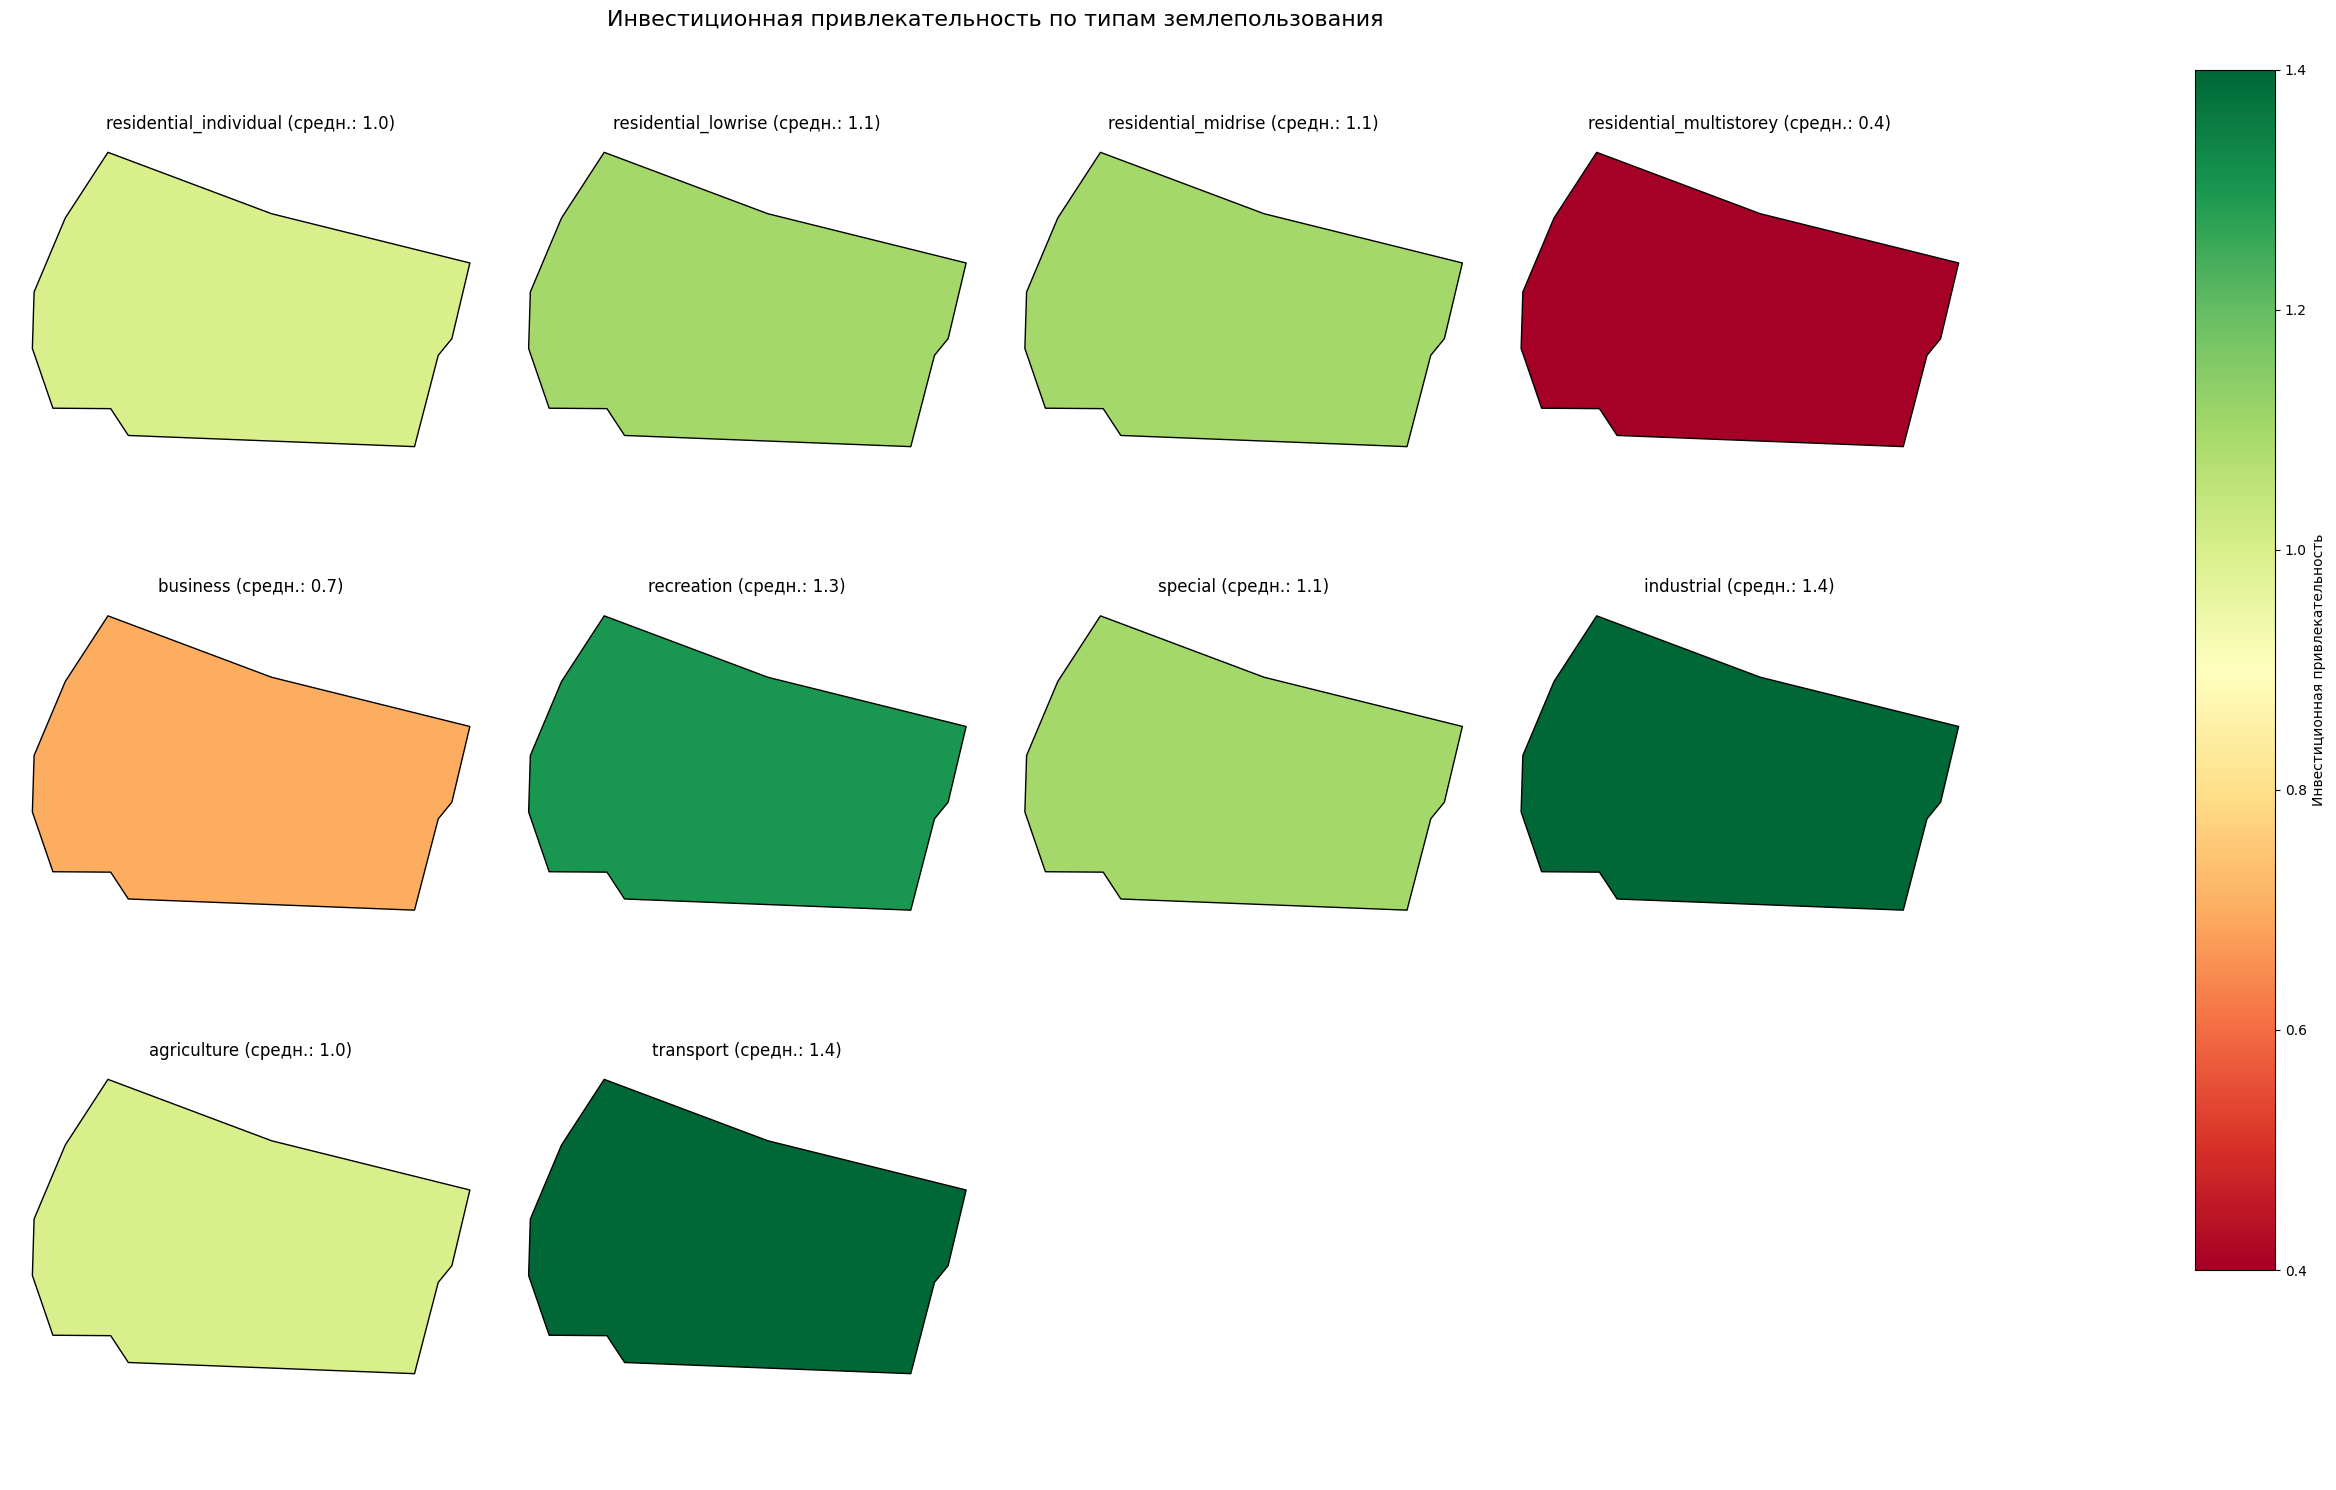

In [2]:
from urbanomy.methods.investment_potential import LandUseInvestmentAnalyzer

# custom_weights = {
#     'residential_individual': {
#         'Население': 1.0,
#         'default': 1.0
#     }
# }

analyzer = LandUseInvestmentAnalyzer(weights=None)
spatial_gdf = analyzer.compute_scores(polygon_gdf)
fig = analyzer.visualize_investment_maps(spatial_gdf)
plt.show()

In [3]:
spatial_gdf

,geometry,Численность населения,Население,Транспортное обеспечение,Экологическая ситуация,Обеспечение инженерной инфраструктурой,Социальное обеспечение,Средняя этажность,Коэффициент застройки,Коэффициент плотности застройки,...,ИП_residential_individual,ИП_residential_lowrise,ИП_residential_midrise,ИП_residential_multistorey,ИП_business,ИП_recreation,ИП_special,ИП_industrial,ИП_agriculture,ИП_transport
0,"POLYGON ((387861.999 6644712.938, 388202.551 6...",0.0,2.0,5.0,-2.66,5.0,4.0,2.0,0.2,0.05,...,1.0,1.1,1.1,0.4,0.7,1.3,1.1,1.4,1.0,1.4


In [8]:
# ---------------------------------------------------------------------------
# 1.  Быстрый генератор денежных потоков по бенчмаркам
# ---------------------------------------------------------------------------
from __future__ import annotations
import math
from typing import Dict, List, Any, Tuple

import numpy as np
import pandas as pd
import geopandas as gpd


class QuickScenarioBuilder:
    """
    Генерирует economic_params для ProfileEconomicsEvaluator
    по "грязным" бенчмаркам: плотность, стоимость, цена/аренда и т.п.

    benchmarks: {
        <profile>: {
            'density'           : FAR,                  # GFA / land_area
            'land_cost'         : ₽/м² земли,
            'cost_build'        : ₽/м² GFA,
            -- вариант 1 (продажа) --
            'price_sale'        : ₽/м² GFA,
            'sale_years'        : int,
            -- вариант 2 (аренда)  --
            'rent_annual'       : ₽/м² GFA/год,
            'rent_years'        : int,
            'occupancy'         : 0…1  (default 0.9),
            --------------------------
            'construction_years': int,   (default 2)
            'discount_rate'     : float, (опц.)
            'opex_rate'         : ₽/м² GFA/год (default 0 if не задан)
        }, ...
    }
    """

    def __init__(self,
                 benchmarks: Dict[str, Dict[str, Any]],
                 base_discount_rate: float = 0.12,
                 area_col: str = "Площадь территории"):
        self.bench = benchmarks
        self.r0 = base_discount_rate
        self.area_col = area_col

    # ---------- публичный интерфейс --------------------------------------- #
    def build(self, gdf: gpd.GeoDataFrame) -> Dict[str, Dict[str, Any]]:
        """
        Возвращает economic_params: {
             profile: {"cashflows": [...], "discount_rate": r},
             ...
        }
        """
        land_area_total = gdf[self.area_col].sum()   # м² земли
        params = {}

        for lu, b in self.bench.items():
            cash = self._make_cashflow(lu, land_area_total, b)
            params[lu] = {
                "cashflows": cash,
                "discount_rate": b.get("discount_rate", self.r0)
            }
        return params

    # ---------- внутренние утилиты ---------------------------------------- #
    def _make_cashflow(self, lu: str, land_area: float,
                       b: Dict[str, Any]) -> List[float]:

        density = b["density"]                 # FAR
        gfa = land_area * density              # продаваемая/сдаваемая площадь

        # ----- отрицательные потоки -----
        land_cost_total = land_area * b.get("land_cost", 0)
        build_cost_total = gfa * b["cost_build"]
        years_build = b.get("construction_years", 2)

        capex_per_year = build_cost_total / years_build
        cashflows = [-land_cost_total - capex_per_year]     # год 0

        for _ in range(1, years_build):
            cashflows.append(-capex_per_year)

        # ----- положительные потоки -----
        opex_rate = b.get("opex_rate", 0)
        start_op_year = years_build

        if "price_sale" in b:                              # модель продажи
            sale_years = b.get("sale_years", 3)
            revenue_total = gfa * b["price_sale"]
            rev_per_year = revenue_total / sale_years

            for y in range(sale_years):
                cashflows.append(rev_per_year - gfa * opex_rate)
        elif "rent_annual" in b:                           # модель аренды
            rent_years = b.get("rent_years", 10)
            occ = b.get("occupancy", 0.9)
            rent_per_year = gfa * b["rent_annual"] * occ

            for y in range(rent_years):
                cashflows.append(rent_per_year - gfa * opex_rate)
        else:
            raise ValueError(f"Profile '{lu}' must have price_sale or rent_annual.")

        return cashflows


# ---------------------------------------------------------------------------
# 2.  Экономический расчёт (тот же Evaluator, но без изменений)
# ---------------------------------------------------------------------------
def _npv(rate: float, cashflows: List[float]) -> float:
    return sum(cf / (1 + rate) ** t for t, cf in enumerate(cashflows))


def _irr(cashflows: List[float], guess: float = 0.1, tol: float = 1e-6,
         max_iter: int = 100) -> float | None:
    rate = guess
    for _ in range(max_iter):
        d_npv = sum(-t * cf / (1 + rate) ** (t + 1)
                    for t, cf in enumerate(cashflows))
        if d_npv == 0:
            break
        rate_new = rate - _npv(rate, cashflows) / d_npv
        if abs(rate_new - rate) < tol:
            return rate_new
        rate = rate_new
    return None


def _payback_period(rate: float, cashflows: List[float]) -> float | None:
    cum = 0.0
    for t, cf in enumerate(cashflows):
        cum += cf / (1 + rate) ** t
        if cum >= 0:
            prev_cum = cum - cf / (1 + rate) ** t
            if cf == 0:
                return t
            return t - (prev_cum / (cf / (1 + rate) ** t))
    return None


class ProfileEconomicsEvaluator:
    ECON_METRICS = ("NPV", "IRR", "ROI", "PP", "EI")

    def __init__(self,
                 economic_params: Dict[str, Dict[str, Any]],
                 discount_rate: float = 0.1):
        self.params = economic_params
        self.r = discount_rate

    def enrich_gdf(self, gdf: gpd.GeoDataFrame
                   ) -> Tuple[gpd.GeoDataFrame, pd.DataFrame]:
        rows = []
        for lu, econ in self.params.items():
            cashflows = econ["cashflows"]
            rate = econ.get("discount_rate", self.r)

            npv = _npv(rate, cashflows)
            irr = _irr(cashflows)
            roi = (sum(cf for cf in cashflows[1:]) / -cashflows[0]
                   if cashflows[0] < 0 else np.nan)
            pp = _payback_period(rate, cashflows)

            ei = 0
            if npv is not None:
                ei += 50 * (1 / (1 + math.exp(-npv / 1e8)))
            if irr is not None:
                ei += 50 * max(0, irr - rate) / (0.3 - rate)
            ei = min(max(ei, 0), 100)

            gdf[f"ECON_NPV_{lu}"] = npv
            gdf[f"ECON_IRR_{lu}"] = irr
            gdf[f"ECON_ROI_{lu}"] = roi
            gdf[f"ECON_PP_{lu}"] = pp
            gdf[f"ECON_EI_{lu}"] = ei

            rows.append({
                "profile": lu,
                "NPV": npv,
                "IRR": irr,
                "ROI": roi,
                "PP_years": pp,
                "EI": ei,
                "investment_attractiveness": gdf[f"ИП_{lu}"].mean()
            })

        summary_df = pd.DataFrame(rows).set_index("profile")
        return gdf, summary_df


# ---------------------------------------------------------------------------
# 3.  Пример bench‑словаря (цифры условные, ₽ 2025, без НДС)
# ---------------------------------------------------------------------------
benchmarks_demo = {
    "residential_individual": {
        "density": 0.25,
        "land_cost": 1500,
        "cost_build": 48_000,
        "price_sale": 92_000,
        "construction_years": 2,
        "sale_years": 3,
        "opex_rate": 800,
        "discount_rate": 0.12
    },
    "residential_lowrise": {
        "density": 0.5,
        "land_cost": 1800,
        "cost_build": 50_000,
        "price_sale": 95_000,
        "construction_years": 2,
        "sale_years": 3,
        "opex_rate": 900
    },
    "residential_midrise": {
        "density": 1.5,
        "land_cost": 2500,
        "cost_build": 55_000,
        "price_sale": 105_000,
        "construction_years": 3,
        "sale_years": 4,
        "opex_rate": 1_200
    },
    "residential_multistorey": {
        "density": 3.0,
        "land_cost": 3000,
        "cost_build": 62_000,
        "price_sale": 120_000,
        "construction_years": 4,
        "sale_years": 5,
        "opex_rate": 1_500
    },
    "business": {
        "density": 2.0,
        "land_cost": 2800,
        "cost_build": 70_000,
        "rent_annual": 9_500,
        "rent_years": 12,
        "occupancy": 0.85,
        "construction_years": 3,
        "opex_rate": 2_000
    },
    "recreation": {
        "density": 0.2,
        "land_cost": 1000,
        "cost_build": 40_000,
        "rent_annual": 6_500,
        "rent_years": 15,
        "occupancy": 0.7,
        "construction_years": 2,
        "opex_rate": 1_000
    },
    "special": {
        "density": 1.0,
        "land_cost": 1200,
        "cost_build": 45_000,
        "rent_annual": 8_000,
        "rent_years": 15,
        "occupancy": 0.8,
        "construction_years": 3,
        "opex_rate": 1_500
    },
    "industrial": {
        "density": 1.0,
        "land_cost": 900,
        "cost_build": 38_000,
        "rent_annual": 5_800,
        "rent_years": 12,
        "occupancy": 0.9,
        "construction_years": 2,
        "opex_rate": 700
    },
    "agriculture": {
        "density": 0.1,
        "land_cost": 300,
        "cost_build": 25_000,
        "rent_annual": 2_500,
        "rent_years": 15,
        "occupancy": 0.95,
        "construction_years": 1,
        "opex_rate": 300
    },
    "transport": {
        "density": 1.2,
        "land_cost": 1_100,
        "cost_build": 32_000,
        "rent_annual": 4_200,
        "rent_years": 15,
        "occupancy": 0.88,
        "construction_years": 3,
        "opex_rate": 1_000
    }
}

# ---------------------------------------------------------------------------
# 4.  Сквозное использование -------------------------------------------------
# ---------------------------------------------------------------------------
# 4.1  spatial_gdf уже содержит колонки `ИП_<lu>` (после LandUseInvestmentAnalyzer)
# >>> spatial_gdf = LandUseInvestmentAnalyzer().compute_scores(spatial_gdf)

# 4.2  Сформировать economic_params
builder = QuickScenarioBuilder(benchmarks_demo, base_discount_rate=0.12,
                               area_col="Площадь территории")
economic_params = builder.build(polygon_gdf)

# 4.3  Посчитать экономические метрики
evaluator = ProfileEconomicsEvaluator(economic_params, discount_rate=0.12)
spatial_gdf, econ_summary = evaluator.enrich_gdf(polygon_gdf)

# 4.4  Смотреть результаты
econ_summary
# econ_summary.to_excel("scenario_summary.xlsx", index=True)

,NPV,IRR,ROI,PP_years,EI,investment_attractiveness
profile,,,,,,
residential_individual,18267.829810,0.223211,2.186667,4.335104,53.671889,0.9
residential_lowrise,43591.312629,0.244137,2.353147,4.229907,59.487903,0.9
residential_midrise,83990.087564,0.177824,3.176667,6.237994,41.072786,0.9
residential_multistorey,69520.064972,0.138291,4.000000,8.559575,30.089521,0.3
business,-395674.647322,0.002774,1.060647,NaN,24.950541,0.6
recreation,-24629.658188,0.020314,1.330000,NaN,24.996921,1.2
special,-86536.331927,0.055876,2.685185,NaN,24.989183,0.9
industrial,-68701.599125,0.050681,1.770854,NaN,24.991412,1.2
agriculture,-8029.257131,0.013527,1.111607,NaN,24.998996,0.9


In [4]:
economic_params

{'residential_individual': {'cashflows': [-43425.0,
   -34740.0,
   43232.0,
   43232.0,
   43232.0],
  'discount_rate': 0.12},
 'residential_lowrise': {'cashflows': [-82797.0,
   -72375.0,
   89069.5,
   89069.5,
   89069.5],
  'discount_rate': 0.12},
 'residential_midrise': {'cashflows': [-173700.0,
   -159225.0,
   -159225.0,
   217559.25,
   217559.25,
   217559.25,
   217559.25],
  'discount_rate': 0.12},
 'residential_multistorey': {'cashflows': [-286605.0,
   -269235.0,
   -269235.0,
   -269235.0,
   390825.00000000006,
   390825.00000000006,
   390825.00000000006,
   390825.00000000006,
   390825.00000000006],
  'discount_rate': 0.12},
 'business': {'cashflows': [-286412.0,
   -270200.0,
   -270200.0,
   70348.5,
   70348.5,
   70348.5,
   70348.5,
   70348.5,
   70348.5,
   70348.5,
   70348.5,
   70348.5,
   70348.5,
   70348.5,
   70348.5],
  'discount_rate': 0.12},
 'recreation': {'cashflows': [-28950.000000000004,
   -23160.000000000004,
   4110.900000000001,
   4110.90000

In [10]:
# ---------------------------------------------------------------------------
# 1.  Synthesizer: spatial ИП  +  economics  →  combined attractiveness
# ---------------------------------------------------------------------------
from __future__ import annotations
from typing import Dict, Any, Tuple

import numpy as np
import pandas as pd
import geopandas as gpd


class InvestmentAttractivenessSynthesizer:
    """
    Формирует новую метрику INV_<lu> как взвешенную сумму:
        INV = w_spatial * S_norm  +  w_economic * E_norm

    • S_norm  – нормированный spatial score   (0–100)
    • E_norm  – нормированный economic score  (по‑умолч. берём EI, 0–100)

    Параметры можно настраивать через weights_dict.
    """

    DEFAULT_WEIGHTS = {
        #           w_spatial,  w_economic
        "residential_individual": (0.4, 0.6),
        "residential_lowrise"   : (0.4, 0.6),
        "residential_midrise"   : (0.5, 0.5),
        "residential_multistorey": (0.5, 0.5),
        "business"              : (0.3, 0.7),
        "recreation"            : (0.6, 0.4),
        "special"               : (0.3, 0.7),
        "industrial"            : (0.35, 0.65),
        "agriculture"           : (0.6, 0.4),
        "transport"             : (0.35, 0.65)
    }

    def __init__(self,
                 weights_dict: Dict[str, Tuple[float, float]] | None = None,
                 econ_metric: str = "EI"):
        """
        Parameters
        ----------
        weights_dict : dict | None
            {'profile': (w_spatial, w_economic), ...}.  Σw = 1.
            Если None – берутся DEFAULT_WEIGHTS.
        econ_metric  : str
            Какой экономический показатель нормировать
            ('EI', 'NPV', 'IRR', 'ROI' – допускаются).
        """
        self.weights = weights_dict or self.DEFAULT_WEIGHTS
        self.metric = econ_metric.upper()

    # --------------------------------------------------------------------- #
    # --------------------------------------------------------------------- #
    def enrich_gdf(self, gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
        """
        Добавляет в gdf колонки INV_<lu> и возвращает его же.
        """
        # соберём граничные значения для нормализации всех профилей
        spatial_vals = []
        econ_vals = []

        for lu in self.weights.keys():
            spatial_vals.extend(gdf[f"ИП_{lu}"].values.astype(float))
            econ_vals.extend(gdf[f"ECON_{self.metric}_{lu}"].values.astype(float))

        s_min, s_max = np.nanmin(spatial_vals), np.nanmax(spatial_vals)
        e_min, e_max = np.nanmin(econ_vals), np.nanmax(econ_vals)

        # если метрика экономическая может быть отрицательной (NPV, ROI)
        if self.metric in ("NPV", "ROI"):
            # нормируем симметрично вокруг 0
            e_abs_max = max(abs(e_min), abs(e_max))
            e_min, e_max = -e_abs_max, e_abs_max

        # ---------- нормализация и расчёт -------------------------------- #
        for lu, (w_s, w_e) in self.weights.items():
            s_raw = gdf[f"ИП_{lu}"].astype(float)
            e_raw = gdf[f"ECON_{self.metric}_{lu}"].astype(float)

            # приведение к 0‒100
            s_norm = 100 * (s_raw - s_min) / (s_max - s_min) if s_max > s_min else 0
            if e_max > e_min:
                e_norm = 100 * (e_raw - e_min) / (e_max - e_min)
            else:
                e_norm = 0

            # итоговое значение с округлением до 2 знаков
            gdf[f"INV_{lu}"] = (w_s * s_norm + w_e * e_norm).round(2)

        return gdf



In [11]:
synth = InvestmentAttractivenessSynthesizer(
            weights_dict=None,       # или передайте свой словарь весов
            econ_metric="EI")        # или "NPV", "IRR", "ROI"

spatial_gdf = synth.enrich_gdf(spatial_gdf)
cols_inv = [c for c in spatial_gdf.columns if c.startswith("INV_")]
spatial_gdf[cols_inv]

,INV_residential_individual,INV_residential_lowrise,INV_residential_midrise,INV_residential_multistorey,INV_business,INV_recreation,INV_special,INV_industrial,INV_agriculture,INV_transport
0,76.56,86.67,56.67,7.44,10.0,60.05,20.08,35.08,40.06,35.07
